In [5]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

In [9]:
base_dir = os.getcwd()
input_path = os.path.join(base_dir, "../data/processed/cleaned.csv")
data = pd.read_csv(input_path)
data.head()

print("Shape of dataset: ", data.shape)
print("Columns: ", data.columns)
print("Data types: ", data.dtypes)
print("Missing values: ", data.isnull().sum())

print("Data info: \n" )
data.info()
print("Data description: \n")
data.describe()

print("null count per columns: \n", data.isnull().sum())
data.dropna(inplace=True)
print("Shape of dataset after dropping nulls: ", data.shape)


Shape of dataset:  (7043, 46)
Columns:  Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges',
       'gender_Female', 'gender_Male', 'Partner_No', 'Partner_Yes',
       'Dependents_No', 'Dependents_Yes', 'PhoneService_No',
       'PhoneService_Yes', 'MultipleLines_No',
       'MultipleLines_No phone service', 'MultipleLines_Yes',
       'InternetService_DSL', 'InternetService_Fiber optic',
       'InternetService_No', 'OnlineSecurity_No',
       'OnlineSecurity_No internet service', 'OnlineSecurity_Yes',
       'OnlineBackup_No', 'OnlineBackup_No internet service',
       'OnlineBackup_Yes', 'DeviceProtection_No',
       'DeviceProtection_No internet service', 'DeviceProtection_Yes',
       'TechSupport_No', 'TechSupport_No internet service', 'TechSupport_Yes',
       'StreamingTV_No', 'StreamingTV_No internet service', 'StreamingTV_Yes',
       'StreamingMovies_No', 'StreamingMovies_No internet service',
       'StreamingMovies_Yes', 'Contract_Month-to-month', 'Contract_

In [15]:
churn_bin = data["Churn"].astype(int)

print("Churn distribution (normalized):")
print(churn_bin.value_counts(normalize=True))

print("Churn percentage:", churn_bin.mean())
numeric_cols = data.select_dtypes(include=["number"]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c.lower() != "churn"]
print("\nSummary stats for numeric columns:")
display(data[numeric_cols].describe())


Churn distribution (normalized):
Churn
0    0.734215
1    0.265785
Name: proportion, dtype: float64
Churn percentage: 0.26578498293515357

Summary stats for numeric columns:


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.162400,32.421786,64.798208,2283.300441
std,0.368844,24.545260,30.085974,2266.771362
min,0.000000,1.000000,18.250000,18.800000
25%,0.000000,9.000000,35.587500,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.862500,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


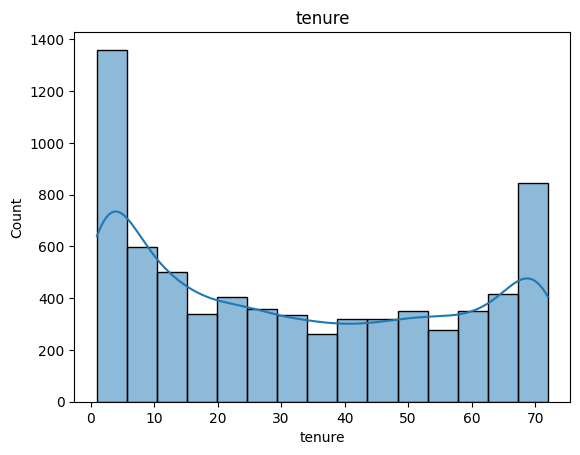

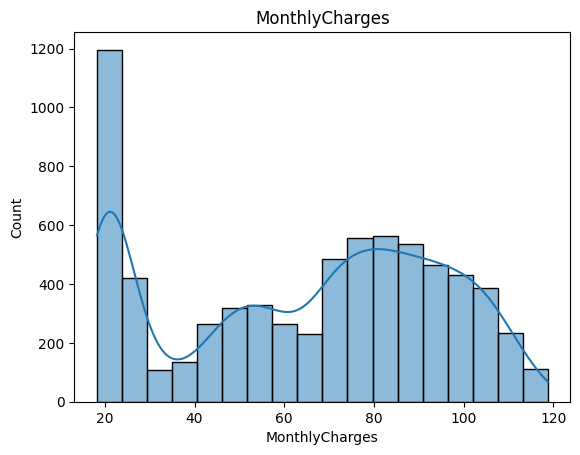

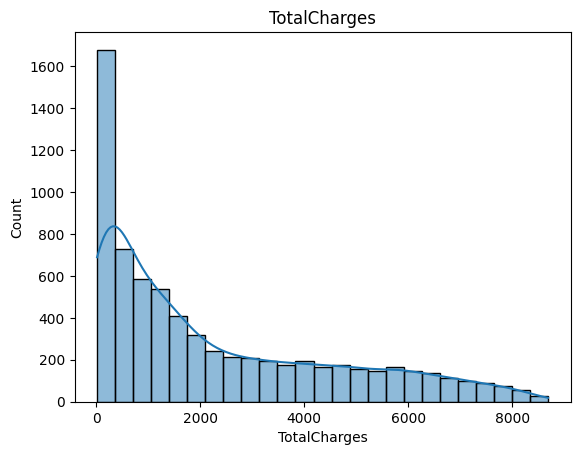

Overall churn rate: 0.26578498293515357
gender_Female                                  support=3483  churn_rate=0.270
gender_Male                                    support=3549  churn_rate=0.262
Partner_No                                     support=3639  churn_rate=0.330
Partner_Yes                                    support=3393  churn_rate=0.197
Dependents_No                                  support=4933  churn_rate=0.313
Dependents_Yes                                 support=2099  churn_rate=0.155
PhoneService_No                                support= 680  churn_rate=0.250
PhoneService_Yes                               support=6352  churn_rate=0.267
MultipleLines_No                               support=3385  churn_rate=0.251
MultipleLines_No phone service                 support= 680  churn_rate=0.250
MultipleLines_Yes                              support=2967  churn_rate=0.286
InternetService_DSL                            support=2416  churn_rate=0.190
InternetService_Fiber op

In [ ]:
data["Churn"].value_counts()
data["Churn"].value_counts(normalize=True)
#Churn is imbalanced, with only about 26.5% of customers churning. This will need to be addressed during modeling, potentially through techniques like resampling or using algorithms that can handle imbalance.

#Numerical visualization
for col in ["tenure","MonthlyCharges","TotalCharges"]:
    sns.histplot(data[col], kde=True)
    plt.title(col)
    plt.show()

#Categorical visualization
print("Overall churn rate:", data["Churn"].mean())
cat_dummy_cols = [c for c in data.columns if data[c].dtype == "bool"]
for col in cat_dummy_cols:
    churn_rate = data.loc[data[col], "Churn"].mean()   # mean churn when this category is True
    support = int(data[col].sum())
    print(f"{col:45s}  support={support:4d}  churn_rate={churn_rate:.3f}")
#The above lets us see what % of customers per category churned, in comparison to our overall churn rate (0.265)
#We can compare the yes/no for each category to see what categories have a higher or lower than average risk rate for churning. For example, customers with "PaperlessBilling" have a much higher churn rate (0.44) than the overall average (0.265), while customers with "Partner" have a much lower churn rate (0.16). This can help us identify which features are most predictive of churn and should be prioritized in our modeling efforts.
#On the other hand, gender and phone service don't seem to have much of an impact on churn, as their churn rates are close to the overall average.


In [ ]:
#We know now that strong predictors of churn include: PaperlessBilling, Contract type, Payment method, and whether the customer has a partner or dependents. Weaker predictors
#include gender and phone service.

baseline = data["Churn"].mean()

rows = []
for col in cat_dummy_cols:
    support = int(data[col].sum())
    churn_rate = data.loc[data[col], "Churn"].mean()
    lift = churn_rate - baseline
    rows.append((col, support, churn_rate, lift))

churn_summary = pd.DataFrame(
    rows, columns=["Feature", "Support", "ChurnRate", "Lift_vs_Baseline"]
).sort_values("Lift_vs_Baseline", ascending=False)

churn_summary.head(10)

,Feature,Support,ChurnRate,Lift_vs_Baseline
39,PaymentMethod_Electronic check,2365,0.452854,0.187069
32,Contract_Month-to-month,3875,0.427097,0.161312
12,InternetService_Fiber optic,3096,0.418928,0.153143
14,OnlineSecurity_No,3497,0.417787,0.152002
23,TechSupport_No,3472,0.416475,0.150690
17,OnlineBackup_No,3087,0.399417,0.133632
20,DeviceProtection_No,3094,0.391403,0.125618
29,StreamingMovies_No,2781,0.337289,0.071504
36,PaperlessBilling_Yes,4168,0.335893,0.070108
26,StreamingTV_No,2809,0.335351,0.069566
